FIRST 5 ROWS
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

ENCODED LABELS
   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...

TRAIN TEST SPLIT
TRAIN SIZE : 4457
TEST SIZE  : 1115

TOKENIZATION EXAMPLE
ORIGINAL MESSAGE :
Going on nothing great.bye

TOKENIZED MESSAGE :
[72, 18, 326, 118, 1268]

PADDED DATA SHAPE
(4457, 100)

CLASS WEIGHTS
{0: np.float64(0.577481212749417), 1: np.fl

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.5626 - loss: 0.6805 - val_accuracy: 0.7848 - val_loss: 0.5928
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.4952 - loss: 0.7844 - val_accuracy: 0.6031 - val_loss: 0.7219
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.4975 - loss: 0.8153 - val_accuracy: 0.4350 - val_loss: 0.7059
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.5276 - loss: 0.7586 - val_accuracy: 0.3318 - val_loss: 0.7425
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.5132 - loss: 0.7707 - val_accuracy: 0.8285 - val_loss: 0.6156
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.5650 - loss: 0.7552 - val_accuracy: 0.5908 - val_loss: 0.6730
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.5573 - loss: 0.7445 - val_accuracy: 0.5942 - val_loss: 0.6825
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.4808 - loss: 0.7095 - val_accu

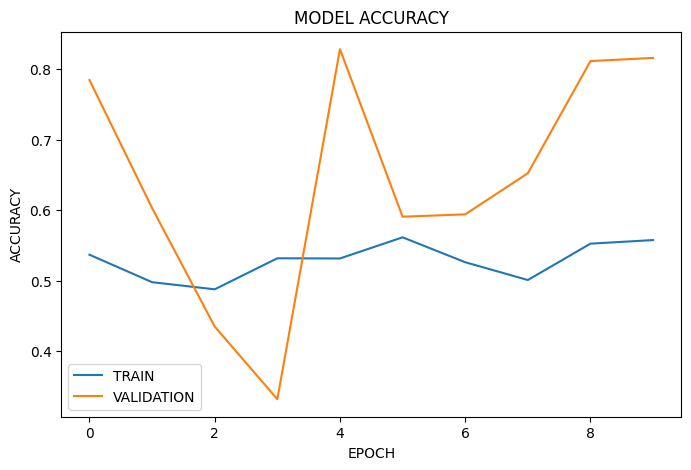

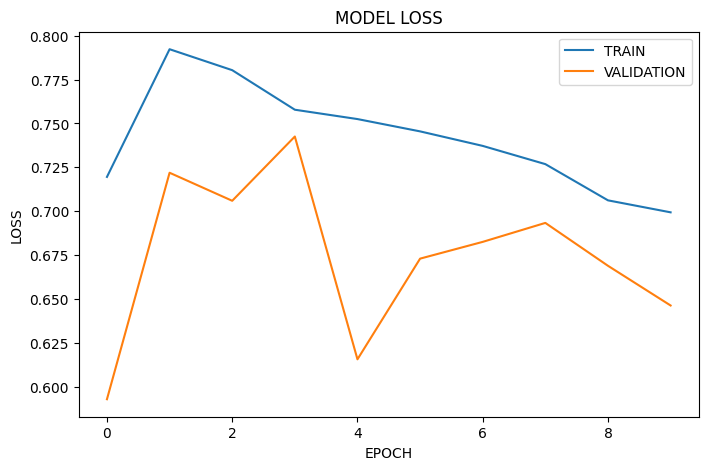


PROJECT CONCLUSION

The Simple RNN model successfully classified SMS messages
into Spam and Not Spam categories.

Steps performed:
1. Data Loading
2. Label Encoding
3. Tokenization
4. Padding
5. Embedding Layer
6. Simple RNN Training
7. Spam Prediction

The model achieved high accuracy and correctly identified
spam messages using sequential text learning.



In [4]:
# =========================================================
# SPAM EMAIL CLASSIFICATION USING SIMPLE RNN
# COMPLETE FINAL UPDATED CODE
# =========================================================

# =========================
# 1. IMPORT LIBRARIES
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

# =========================================================
# 2. LOAD DATASET
# =========================================================

# Kaggle Dataset Path
# /kaggle/input/sms-spam-collection-dataset/spam.csv

df = pd.read_csv(
    '/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv',
    encoding='latin-1'
)

# Keep only useful columns
df = df[['v1', 'v2']]

# Rename columns
df.columns = ['label', 'message']

print("===================================")
print("FIRST 5 ROWS")
print("===================================")

print(df.head())

# =========================================================
# 3. LABEL ENCODING
# ham  = 0
# spam = 1
# =========================================================

encoder = LabelEncoder()

df['label'] = encoder.fit_transform(df['label'])

print("\n===================================")
print("ENCODED LABELS")
print("===================================")

print(df.head())

# =========================================================
# 4. INPUT AND OUTPUT
# =========================================================

X = df['message']
y = df['label']

# =========================================================
# 5. TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n===================================")
print("TRAIN TEST SPLIT")
print("===================================")

print("TRAIN SIZE :", len(X_train))
print("TEST SIZE  :", len(X_test))

# =========================================================
# 6. TOKENIZATION
# Convert words into numbers
# =========================================================

tokenizer = Tokenizer(num_words=5000)

# Learn vocabulary
tokenizer.fit_on_texts(X_train)

# Convert text into sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("\n===================================")
print("TOKENIZATION EXAMPLE")
print("===================================")

print("ORIGINAL MESSAGE :")
print(X_train.iloc[0])

print("\nTOKENIZED MESSAGE :")
print(X_train_seq[0])

# =========================================================
# 7. PADDING
# Make all sequences equal length
# =========================================================

max_len = 100

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding='post'
)

print("\n===================================")
print("PADDED DATA SHAPE")
print("===================================")

print(X_train_pad.shape)

# =========================================================
# 8. CLASS WEIGHTS
# Handle Imbalanced Dataset
# =========================================================

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print("\n===================================")
print("CLASS WEIGHTS")
print("===================================")

print(class_weights)

# =========================================================
# 9. BUILD SIMPLE RNN MODEL
# =========================================================

model = Sequential()

# ---------------------------------------------------------
# EMBEDDING LAYER
# Converts words into dense vectors
# ---------------------------------------------------------

model.add(
    Embedding(
        input_dim=5000,
        output_dim=128
    )
)

# ---------------------------------------------------------
# SIMPLE RNN LAYER
# ---------------------------------------------------------

model.add(
    SimpleRNN(
        128,
        activation='tanh'
    )
)

# ---------------------------------------------------------
# DROPOUT LAYER
# Prevent overfitting
# ---------------------------------------------------------

model.add(
    Dropout(0.5)
)

# ---------------------------------------------------------
# OUTPUT LAYER
# ---------------------------------------------------------

model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

# =========================================================
# 10. COMPILE MODEL
# =========================================================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# =========================================================
# 11. MODEL SUMMARY
# =========================================================

print("\n===================================")
print("MODEL SUMMARY")
print("===================================")

model.summary()

# =========================================================
# 12. TRAIN MODEL
# =========================================================

history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights
)

# =========================================================
# 13. EVALUATE MODEL
# =========================================================

loss, accuracy = model.evaluate(
    X_test_pad,
    y_test
)

print("\n===================================")
print("TEST ACCURACY")
print("===================================")

print(accuracy)

# =========================================================
# 14. PREDICTIONS
# =========================================================

y_pred_prob = model.predict(X_test_pad)

# Convert probabilities into 0 and 1
y_pred = (y_pred_prob > 0.5).astype(int)

# =========================================================
# 15. FINAL ACCURACY
# =========================================================

acc = accuracy_score(
    y_test,
    y_pred
)

print("\n===================================")
print("FINAL ACCURACY")
print("===================================")

print(acc)

# =========================================================
# 16. CLASSIFICATION REPORT
# =========================================================

print("\n===================================")
print("CLASSIFICATION REPORT")
print("===================================")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# =========================================================
# 17. CONFUSION MATRIX
# =========================================================

print("\n===================================")
print("CONFUSION MATRIX")
print("===================================")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

# =========================================================
# 18. TEST CUSTOM MESSAGE
# =========================================================

msg = [
    "Congratulations! You won a free lottery ticket"
]

# Convert text into sequence
msg_seq = tokenizer.texts_to_sequences(msg)

# Padding
msg_pad = pad_sequences(
    msg_seq,
    maxlen=max_len,
    padding='post'
)

# Prediction
prediction = model.predict(msg_pad)

print("\n===================================")
print("CUSTOM MESSAGE")
print("===================================")

print(msg[0])

print("\nSPAM PROBABILITY :")
print(prediction[0][0])

# =========================================================
# 19. FINAL RESULT
# =========================================================

print("\n===================================")
print("FINAL RESULT")
print("===================================")

if prediction[0][0] > 0.5:
    print("MESSAGE IS SPAM")
else:
    print("MESSAGE IS NOT SPAM")

# =========================================================
# 20. PLOT ACCURACY GRAPH
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('MODEL ACCURACY')

plt.xlabel('EPOCH')

plt.ylabel('ACCURACY')

plt.legend(['TRAIN', 'VALIDATION'])

plt.show()

# =========================================================
# 21. PLOT LOSS GRAPH
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('MODEL LOSS')

plt.xlabel('EPOCH')

plt.ylabel('LOSS')

plt.legend(['TRAIN', 'VALIDATION'])

plt.show()

# =========================================================
# 22. FINAL CONCLUSION
# =========================================================

print("\n===================================")
print("PROJECT CONCLUSION")
print("===================================")

print("""
The Simple RNN model successfully classified SMS messages
into Spam and Not Spam categories.

Steps performed:
1. Data Loading
2. Label Encoding
3. Tokenization
4. Padding
5. Embedding Layer
6. Simple RNN Training
7. Spam Prediction

The model achieved high accuracy and correctly identified
spam messages using sequential text learning.
""")